# TME Music Data Analysis Pipeline
This notebook imports modularized functions from `pipeline`, `reporting`, and `plotting` to perform ETL, analysis, and report generation.

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [232]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting

## 1. Run ETL Pipeline
Extract data from all raw TME Excel files, calculate platform-specific click metrics, and clean the dataset.

In [212]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/sony_TME/大曲庫/2025/ 
 ../output/TME_Song_Report_for_Sony_大曲庫-2025.xlsx


In [213]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 728330 entries, 149263 to 298528
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Platform         728330 non-null  object 
 1   YearMonth        728330 non-null  object 
 2   Album            728204 non-null  object 
 3   Song             728259 non-null  object 
 4   Artist           728086 non-null  object 
 5   UPC              112827 non-null  object 
 6   ISRC             728330 non-null  object 
 7   Revenue          728330 non-null  float64
 8   Total_Clicks     728330 non-null  float64
 9   source_file      728330 non-null  object 
 10  standard_song    728259 non-null  object 
 11  standard_artist  728086 non-null  object 
dtypes: float64(2), object(10)
memory usage: 72.2+ MB


In [214]:
df_cleaned.head()

,Platform,YearMonth,Album,Song,Artist,UPC,ISRC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
149263,Wesing,2025-01,守护神之保险调查 电视剧原声带,守护英雄,张玮,NaN,TWX351800150,0.000,0.0,k_outside_detail_T8MY-OTHER-2021112400003_3049...,守护英雄,张玮
129697,QQMusic,2025-01,梦想星搭档第二季 公益盛典,欢乐中国年 + 恭喜恭喜(Live),华语群星,NaN,欢乐中国年 + 恭喜恭喜(LIVE) - 华语群星,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,欢乐中国年 + 恭喜恭喜(Live),华语群星
129698,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹
129699,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹
129700,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,1.008,2.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,revenue,clicks,MoM_Growth_Pct
0,2025-01,9.302003e+05,1.586329e+08,N/A
1,2025-02,9.017148e+05,1.543466e+08,-3.06%
2,2025-03,9.484426e+05,1.945671e+08,5.18%
3,2025-04,9.525629e+05,1.924726e+08,0.43%
4,2025-05,1.033833e+06,1.938641e+08,8.53%
5,2025-06,9.472260e+05,1.661119e+08,-8.38%
6,2025-07,9.234500e+05,1.777543e+08,-2.51%
7,2025-08,9.586175e+05,1.800378e+08,3.81%
8,2025-09,9.379652e+05,1.631248e+08,-2.15%
9,2025-10,9.558818e+05,1.667007e+08,1.91%


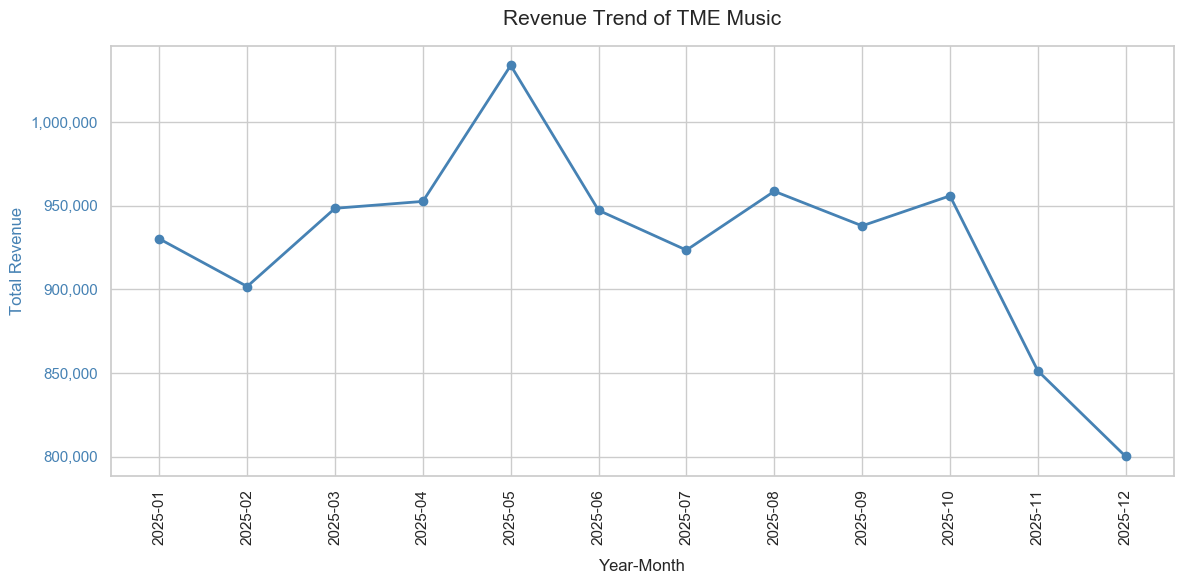

In [215]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['MoM_Growth_Pct'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph
plotting.plot_revenue_trend(revenue_by_month)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [216]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 728330 rows.


## Top Songs Share & Pie Charts

In [217]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

Top 10 songs contribute to 78.13% of total revenue.


,UPC,ISRC,song,artist,revenue,clicks,rev_share,click_share
1006,UPC-828767536125,TWC230515112,恶作剧,王蓝茵,1.085227e+06,222439786.0,0.322786,0.343193
521,UPC-4712505300245,TWI431603105,漂洋过海来看你,刘明湘,4.512946e+05,59986962.0,0.134232,0.092551
999,UPC-828767536125,TWC230515103,遇到,方雅贤,3.436953e+05,72071182.0,0.102228,0.111196
245,UPC-4710635380335,TWC230107211,屋顶,"温岚,周杰伦",1.819245e+05,42298331.0,0.054111,0.065260
979,UPC-828767296425,TWC230514205,牡丹江,南拳妈妈,1.459491e+05,29803734.0,0.043411,0.045983
717,UPC-4712505304045,TWI430700103,醉清风,弦子,1.163305e+05,20146188.0,0.034601,0.031083
722,UPC-4712505304045,TWI430800205,舍不得,弦子,9.538438e+04,17285631.0,0.028371,0.026669
998,UPC-828767536125,TWC230515102,Say U Love Me,"南拳妈妈,JZN",7.980371e+04,13478204.0,0.023737,0.020795
981,UPC-828767296425,TWC230514207,橘子汽水,南拳妈妈,6.428180e+04,14096723.0,0.019120,0.021749
966,UPC-8287661891242,TWC230414102,香草吧噗,南拳妈妈,6.293230e+04,13500778.0,0.018718,0.020830


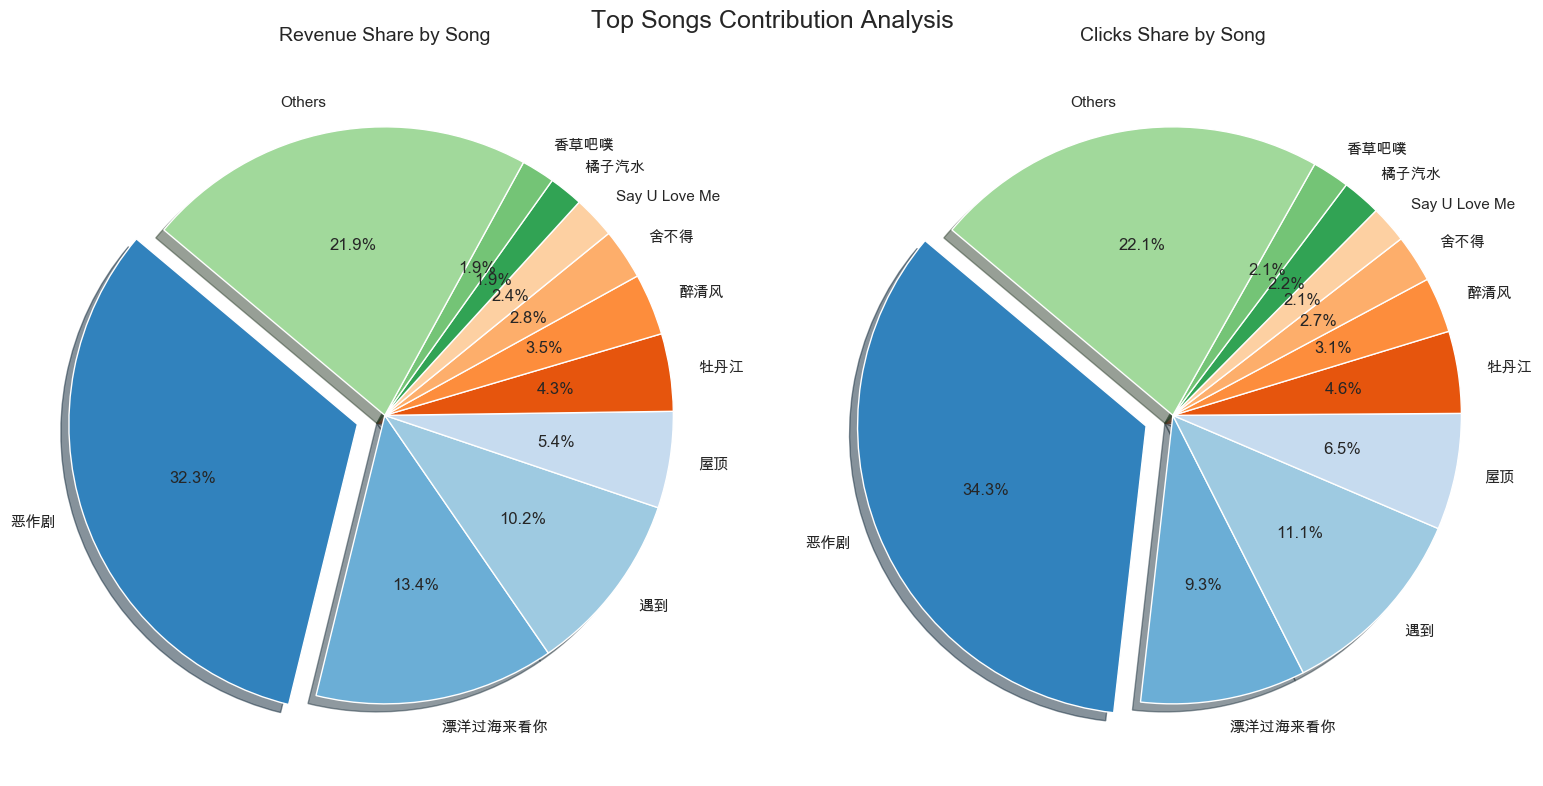

In [218]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)
plotting.plot_pie_charts(df_pie)

## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [233]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)

Song report exported successfully to: ../output/TME_Song_Report_Monthly_for_Sony_大曲庫-2025.xlsx


In [220]:
song_final.head()

,ISRC,song,artist,UPC,album,total_click,total_revenue,2025-01_clicks,2025-01_revenue,2025-02_clicks,...,2025-08_clicks,2025-08_revenue,2025-09_clicks,2025-09_revenue,2025-10_clicks,2025-10_revenue,2025-11_clicks,2025-11_revenue,2025-12_clicks,2025-12_revenue
0,TWC230515112,恶作剧,王蓝茵,UPC-828767536125,恶作剧之吻 电视剧原声带,222439786.0,1.085227e+06,18244455.0,104465.621826,16750509.0,...,19551085.0,92520.505206,16911594.0,87563.060316,17755431.0,92547.295120,16920393.0,83858.981614,17712746.0,82249.244169
1,TWI431603105,漂洋过海来看你,刘明湘,UPC-4712505300245,我不要再比了,59986962.0,4.512946e+05,0.0,0.000000,5167583.0,...,5120422.0,37735.712816,4843138.0,38841.180025,5586138.0,44015.840637,5349439.0,40290.560442,5532760.0,40257.166800
2,TWC230515103,遇到,方雅贤,UPC-828767536125,恶作剧之吻 电视剧原声带,72071182.0,3.436953e+05,5309342.0,30134.852082,4860467.0,...,6571331.0,30612.444688,5837432.0,30271.158690,5924374.0,30373.683705,5511271.0,27406.163085,5858819.0,27297.963643
3,TWC230107211,屋顶,"温岚,周杰伦",UPC-4710635380335,爱回温,42298331.0,1.819245e+05,2826212.0,15721.837722,2540829.0,...,4143723.0,16510.949614,3965474.0,17809.686885,4171578.0,18400.078671,3854632.0,16165.251385,3788060.0,15529.051369
4,TWC230514205,牡丹江,南拳妈妈,UPC-828767296425,2号餐,29803734.0,1.459491e+05,2197441.0,12076.097429,2232677.0,...,2476783.0,12432.215776,2331140.0,12291.221615,2308601.0,12588.103736,2326935.0,11380.736975,2287652.0,11222.404234


## Generate Song Report by Year

In [221]:
df_filtered.head()

,Platform,YearMonth,Album,Song,Artist,UPC,ISRC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
149263,Wesing,2025-01,守护神之保险调查 电视剧原声带,守护英雄,张玮,NaN,TWX351800150,0.000,0.0,k_outside_detail_T8MY-OTHER-2021112400003_3049...,守护英雄,张玮
129697,QQMusic,2025-01,梦想星搭档第二季 公益盛典,欢乐中国年 + 恭喜恭喜(Live),华语群星,NaN,欢乐中国年 + 恭喜恭喜(LIVE) - 华语群星,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,欢乐中国年 + 恭喜恭喜(Live),华语群星
129698,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹
129699,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,0.504,1.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹
129700,QQMusic,2025-01,梦想星搭档第二季 公益盛典,宁夏(Live),梁静茹,NaN,宁夏(LIVE) - 梁静茹,1.008,2.0,single_outside_detail_T8MY-OTHER-2021112400003...,宁夏(Live),梁静茹


In [224]:
song_final = generate_song_report_by_year(df_filtered, OUTPUT_SONG_REPORT_PATH)
song_final.head()

Yearly song report exported successfully to: ../output/TME_Song_Report_for_Sony_大曲庫-2025.xlsx


,ISRC,song,artist,total_click,total_revenue,2025_clicks,2025_revenue
0,TWF710700026,同手同脚,温岚,161997146.0,1.106675e+06,161997146.0,1.106675e+06
1,TWC230515112,恶作剧,王蓝茵,222439786.0,1.085227e+06,222439786.0,1.085227e+06
2,TWC230814104,下雨天,南拳妈妈,134893683.0,7.922722e+05,134893683.0,7.922722e+05
3,夏天的风 - 温岚,夏天的风,温岚,95097349.0,5.013694e+05,95097349.0,5.013694e+05
4,TWI431603105,漂洋过海来看你,刘明湘,59986962.0,4.512946e+05,59986962.0,4.512946e+05


## Monthly Revenue Trend for Top Songs

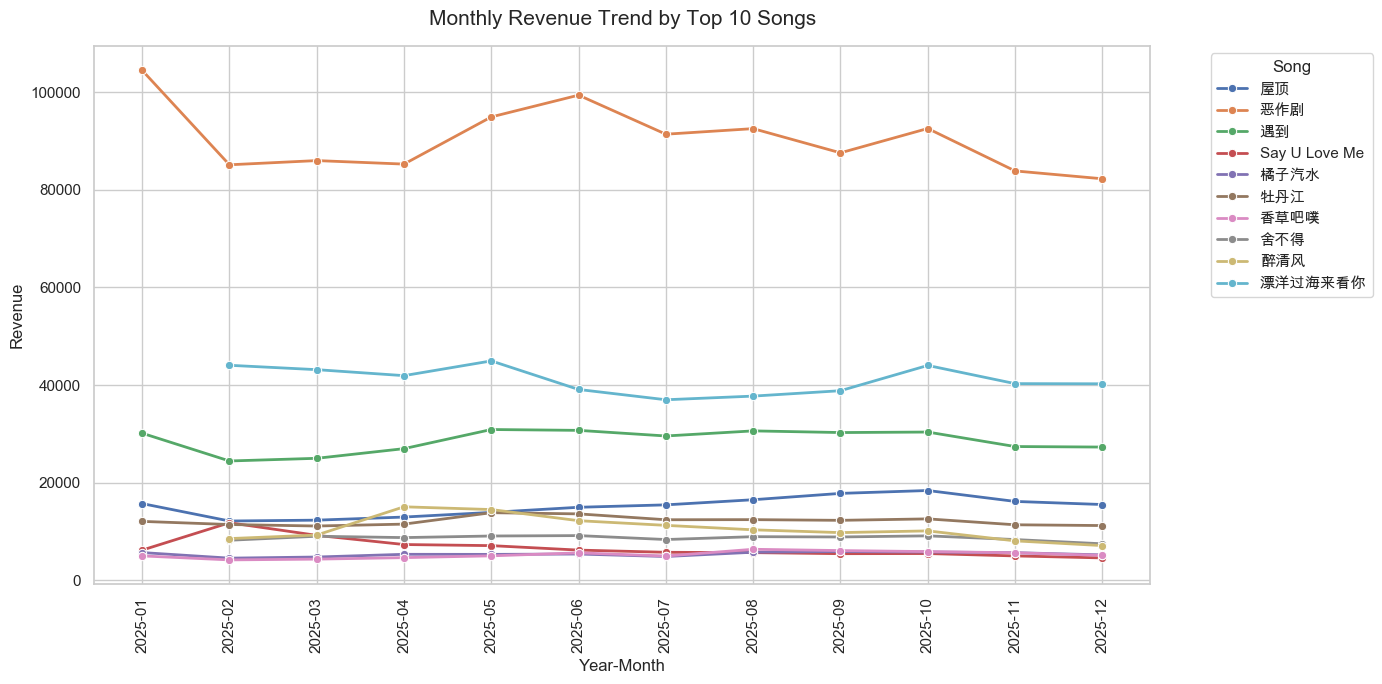

In [225]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['UPC', 'ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[
    revenue_by_song_per_month['ISRC'].isin(top_song_list)
].sort_values('YearMonth')

plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS)

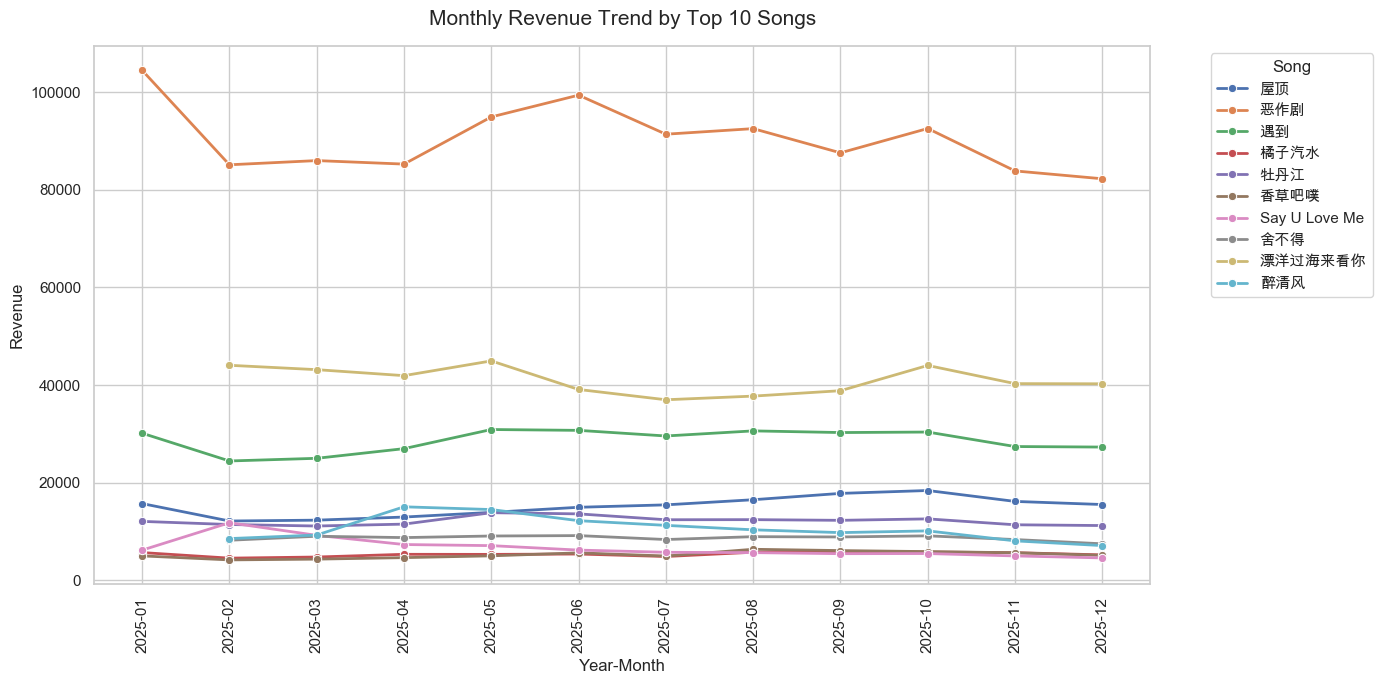

In [226]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[
    revenue_by_song_per_month['ISRC'].isin(top_song_list)
].sort_values('YearMonth')

plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS)

## Revenue by Platform

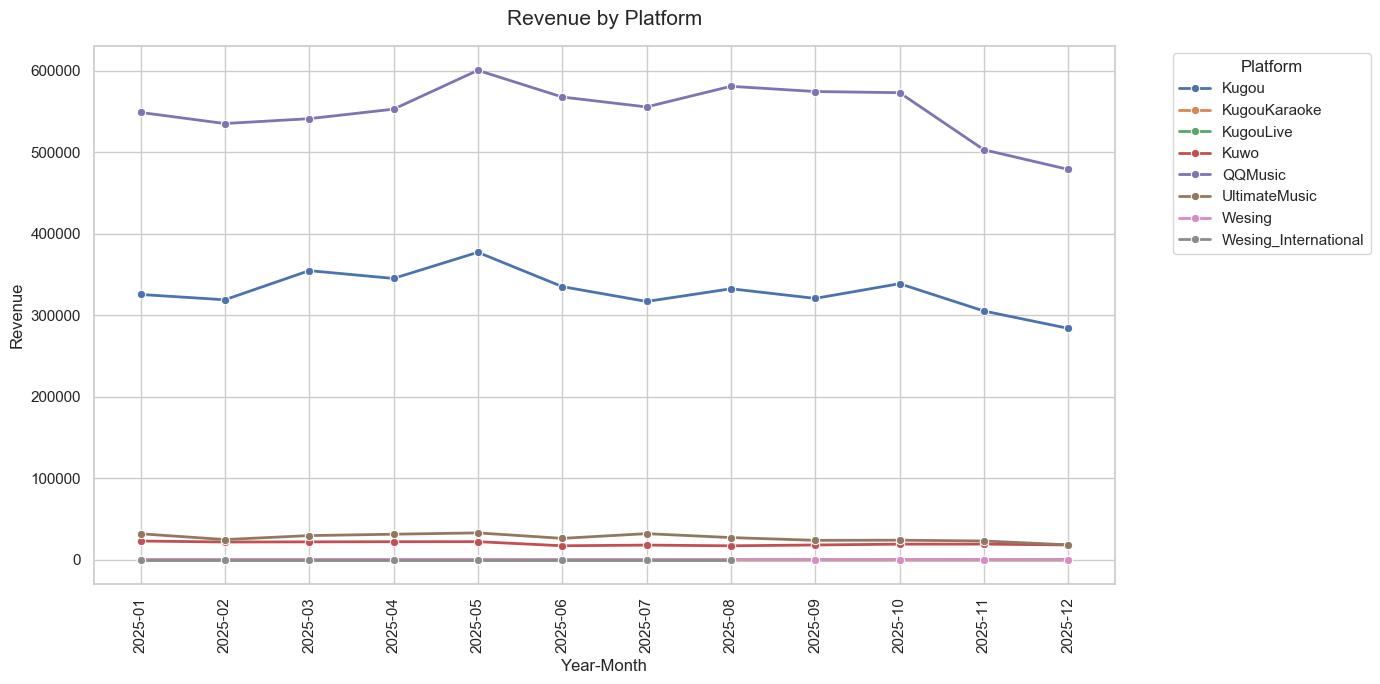

In [227]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

plotting.plot_revenue_by_platform(revenue_by_platform)

In [228]:
revenue_by_platform['Platform'].value_counts()

Platform
Kugou                   12
KugouKaraoke            12
KugouLive               12
Kuwo                    12
QQMusic                 12
UltimateMusic           12
Wesing                  12
Wesing_International     8
Name: count, dtype: int64

## Generate Album Report & Plot Revenue by Album

Top 10 albums contribute to 91.36% of total revenue.


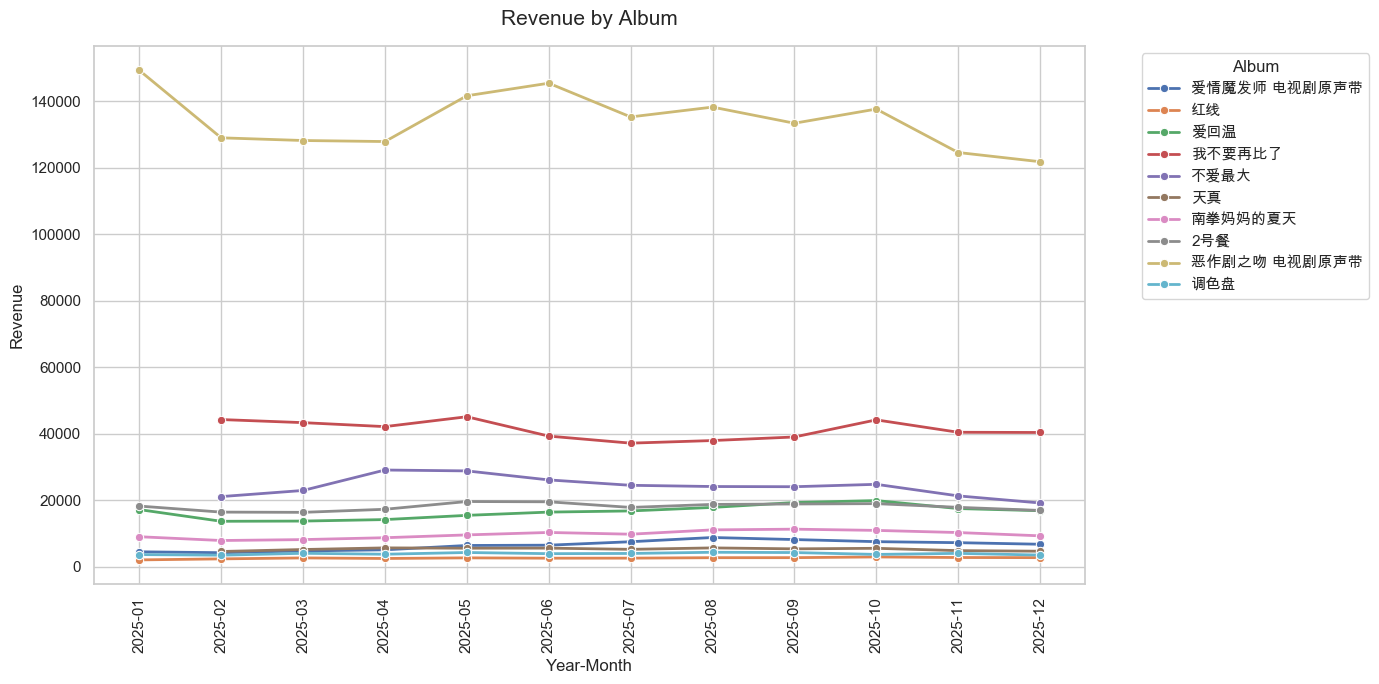

In [229]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]
plotting.plot_revenue_by_album(top_album_trend)